In [1]:
import os
import pandas as pd 
import tempfile 
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")


# --- Start of Notebook Cell ---
actual_file = []
main_path = "/home/rajesh/work/acclerometer_project/zip_data"

if os.path.exists(main_path):
    for zip_file in os.listdir(main_path):
        if zip_file.endswith(".zip"):
            with tempfile.TemporaryDirectory() as temp_dir:
                try:
                    with zipfile.ZipFile(os.path.join(main_path, zip_file), "r") as zf:
                        zf.extractall(temp_dir)
                        for root, dirs, files in os.walk(temp_dir):
                            for d in dirs:
                                if d.startswith('Processed'):
                                    sec_path = os.path.join(root, d)
                                    for f in os.listdir(sec_path):
                                        if f.endswith(('.xls', '.xlsx')):
                                            actual_file.append(pd.read_excel(os.path.join(sec_path, f)))
                except Exception as e: print(f"Error: {e}")
    if actual_file: df_raw = pd.concat(actual_file)
    else: print("No data found in zip files.")
else: print(f"Main path does not exist: {main_path}")


# --- Start of Notebook Cell ---
if 'df_raw' in locals():
    df_raw['behavioral_category']= df_raw['behavioral_category'].apply(lambda x : 'Resting' if x=='Resting Ruminating' else x)
    print(df_raw['behavioral_category'].unique())
else:
    print("df_raw not loaded. Please check data loading step.")


Using device: cuda
['Resting' 'Walking' 'Grazing']


In [2]:
class AdaptiveAccelPipeline:
    def __init__(self, df):
        self.df = df.copy()
        self.df["local_ts"] = pd.to_datetime(self.df["local_ts"])
        self.df = self.df.sort_values(["subject", "local_ts"])

    def filter(self, cutoff=5.0):
        def f(g):
            dt = g["local_ts"].diff().dt.total_seconds()
            dt = dt[dt > 0]
            if len(dt) < 10:
                return g
            fs = 1 / dt.median()
            nyq = fs * 0.5
            if fs <= cutoff * 2:
                return g
            b, a = butter(4, cutoff / nyq, btype="low")
            for c in ["x", "y", "z"]:
                g[c] = filtfilt(b, a, g[c])
            return g
        self.df = self.df.groupby("subject", group_keys=False).apply(f)

    def features(self):
        scale = 16384
        self.df["x_g"] = self.df["x"] / scale
        self.df["y_g"] = self.df["y"] / scale
        self.df["z_g"] = self.df["z"] / scale
        self.df["mag"] = np.sqrt(
            self.df["x_g"]**2 +
            self.df["y_g"]**2 +
            self.df["z_g"]**2
        )
        self.df["enmo"] = np.maximum(self.df["mag"] - 1, 0)
        self.df["odba"] = (
            (self.df["x_g"] - self.df["x_g"].mean()).abs() +
            (self.df["y_g"] - self.df["y_g"].mean()).abs() +
            (self.df["z_g"] - self.df["z_g"].mean()).abs()
        )

    def resample(self, window=10, thresh=0.7):
        def labeler(x):
            vc = x.value_counts(normalize=True)
            if len(vc) and vc.iloc[0] >= thresh:
                return vc.index[0]
            return np.nan

        agg = {
            "x_g": ["mean", "std"],
            "y_g": ["mean", "std"],
            "z_g": ["mean", "std"],
            "mag": ["mean", "std"],
            "enmo": ["mean", "max"],
            "odba": ["mean", "std"],
            "behavioral_category": labeler
        }

        out = (
            self.df.set_index("local_ts")
            .groupby("subject")
            .resample(f"{window}s")
            .agg(agg)
        )

        out.columns = [f"{a}_{b}" if b else a for a, b in out.columns]
        out = out.rename(columns={"behavioral_category_labeler": "label"})
        return out.dropna(subset=["label"]).reset_index()

    def sequences(self, df, feats, target, steps):
        X, y, s = [], [], []
        for sub, g in df.groupby("subject"):
            g = g.sort_values("local_ts")
            if len(g) <= steps:
                continue
            for i in range(len(g) - steps):
                X.append(g[feats].values[i:i+steps])
                y.append(g[target].iloc[i+steps])
                s.append(sub)
        return np.array(X), np.array(y), np.array(s)


# --- Start of Notebook Cell ---
class GatedConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dropout_rate=0.2):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding='same')
        self.gate = nn.Conv1d(in_channels, out_channels, kernel_size, padding='same')
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Apply convolution and sigmoid to generate gate
        g = torch.sigmoid(self.gate(x))
        # Apply convolution for the main path
        c = F.relu(self.conv(x))
        # Element-wise multiplication for gating
        out = c * g
        return self.dropout(out)

class GatedConvNet(nn.Module):
    def __init__(self, input_dim, sequence_length, hidden_dim, classes):
        super().__init__()
        self.input_dim = input_dim
        self.sequence_length = sequence_length
        
        # First, a linear layer to project input_dim to a suitable channel size for Conv1d
        # Conv1d expects (batch, channels, sequence_length)
        self.input_projection = nn.Linear(input_dim, hidden_dim)

        self.gated_conv1 = GatedConvBlock(hidden_dim, hidden_dim, kernel_size=3)
        self.gated_conv2 = GatedConvBlock(hidden_dim, hidden_dim, kernel_size=3)
        
        # Global average pooling to reduce sequence_length dimension
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_dim)
        
        # Project input features
        x = self.input_projection(x)
        
        # Permute to (batch_size, input_dim, sequence_length) for Conv1d
        x = x.permute(0, 2, 1)
        
        x = self.gated_conv1(x)
        x = self.gated_conv2(x)
        
        x = self.pool(x).squeeze(-1) # Output shape (batch_size, hidden_dim)
        out = self.fc(x)
        return out


# --- Start of Notebook Cell ---
class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False):
        x = src
        if self.norm_first:
            x = self.norm1(x)
        
        # MultiheadAttention returns attn_output, attn_output_weights
        attn_output, attn_output_weights = self.self_attn(
            x, x, x,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            is_causal=is_causal
        )
        
        x = src + self.dropout1(attn_output)
        if not self.norm_first:
            x = self.norm1(x)

        if self.norm_first:
            x = self.norm2(x)
        x = x + self.dropout2(self.linear2(self.dropout(self.activation(self.linear1(x)))))
        if not self.norm_first:
            x = self.norm2(x)
        return x, attn_output_weights


class TransformerModel(nn.Module):
    def __init__(self, input_dim, heads, layers, classes):
        super().__init__()
        # Use our custom encoder layer
        enc_layer = CustomTransformerEncoderLayer(
            d_model=input_dim,
            nhead=heads,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, layers)
        self.fc = nn.Linear(input_dim, classes)

    def forward(self, x):
        # The TransformerEncoder will now return a list of (output, attn_weights) from each layer
        # However, nn.TransformerEncoder itself does not directly return per-layer attention weights
        # from its forward pass if it's composed of custom layers that return more than one output.
        # To get attention weights from *all* layers, we'd need to manually loop through layers 
        # or modify TransformerEncoder. For simplicity, we'll demonstrate getting attention from the *last* layer
        # by adapting the forward pass slightly.

        all_attention_weights = []
        # Manually apply encoder layers to collect attention weights
        # This is a simplified approach; a more robust solution would modify TransformerEncoder.
        for layer_idx, layer in enumerate(self.encoder.layers):
            if isinstance(layer, CustomTransformerEncoderLayer):
                x, attn_weights = layer(x) # Custom layer returns output and weights
                all_attention_weights.append(attn_weights)
            else:
                x = layer(x) # Standard layer, no attention weights returned

        # If there are attention weights, take the last one (from the last layer)
        final_attn_weights = all_attention_weights[-1] if all_attention_weights else None

        # Take the output of the last time step for classification
        logits = self.fc(x[:, -1, :])
        
        return logits, final_attn_weights


# --- Start of Notebook Cell ---
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


 TOTAL NUMBER OF ANIMALS: 7


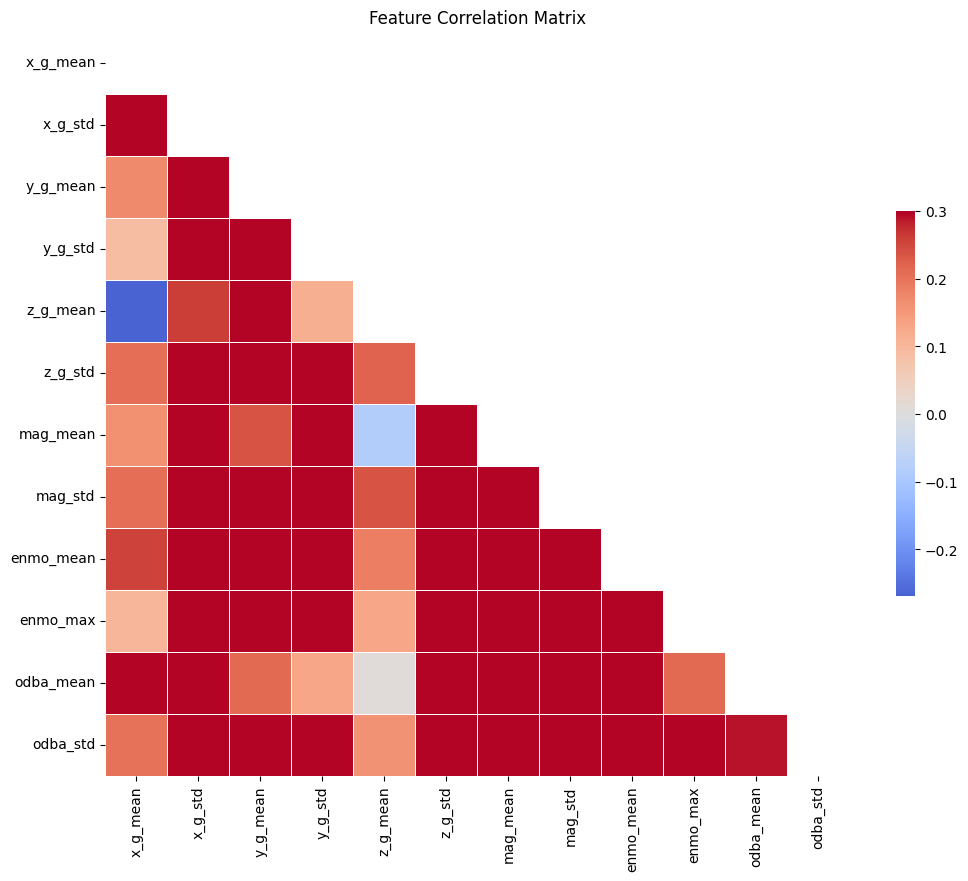

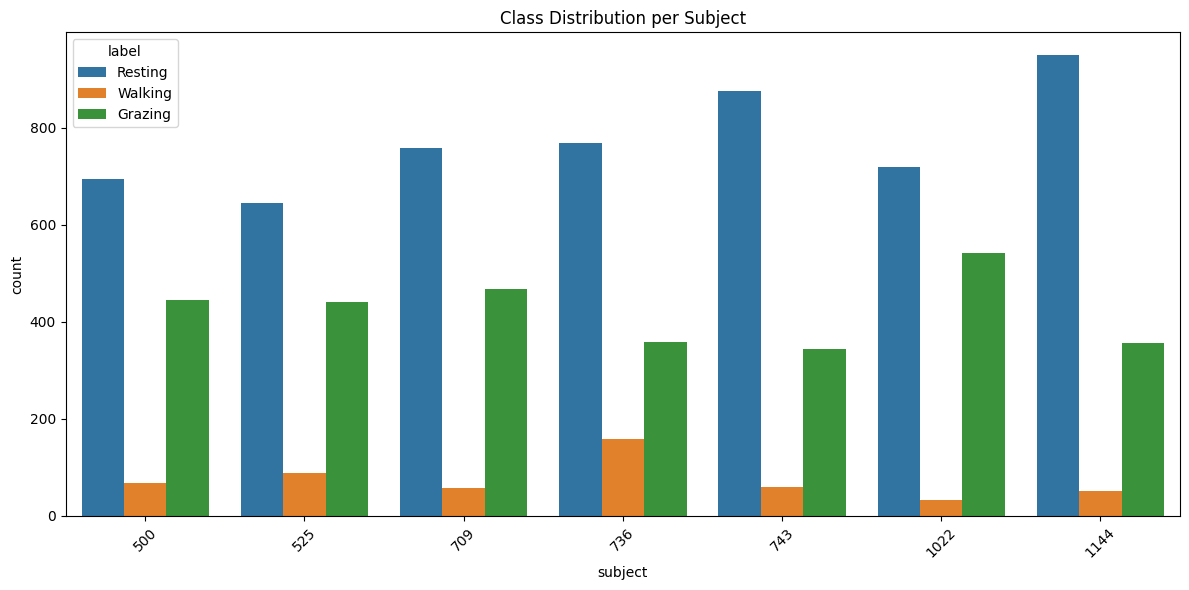

--- Training RNN ---
Starting LOSO for RNN on 7 subjects...
Overall RNN Results:
(0.7740094674189564, 0.6727752730059438, 0.691533487072365, None)


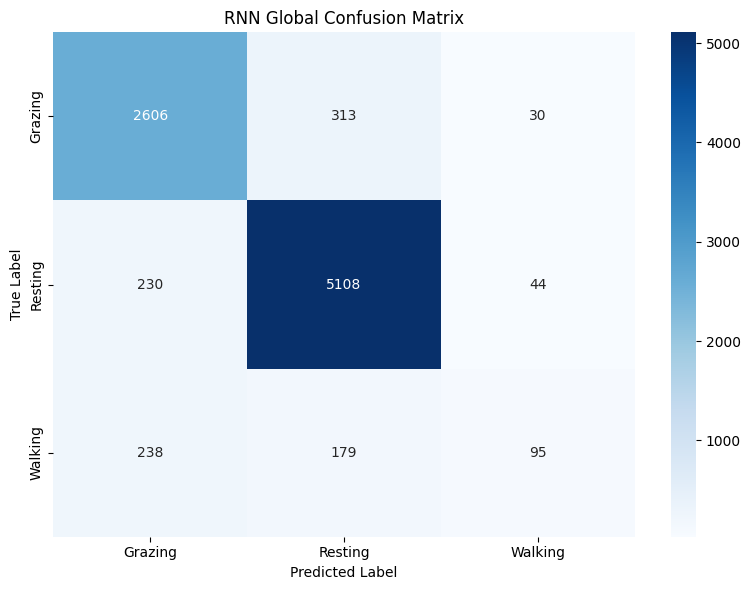

--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


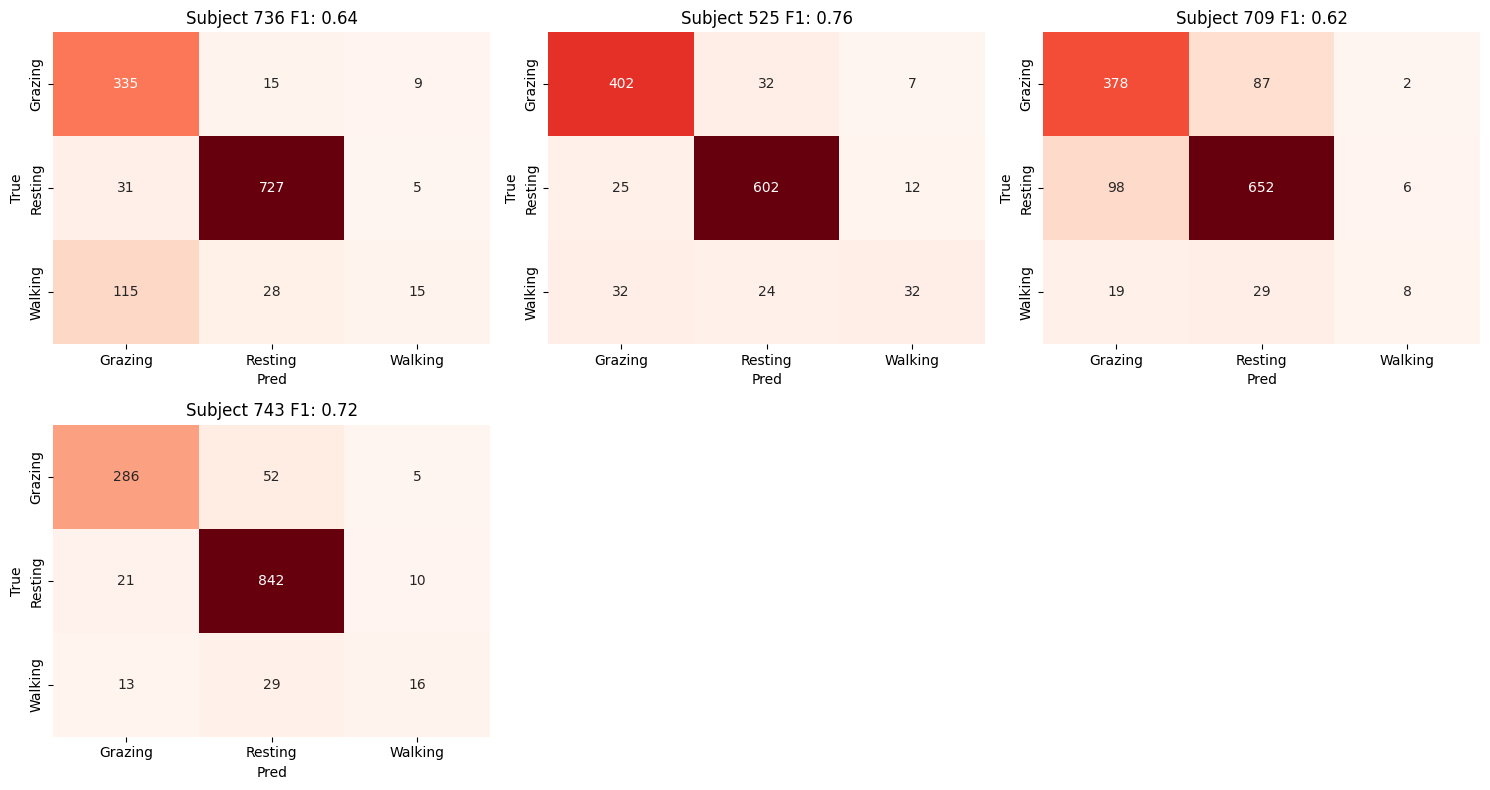

--- Training LSTM ---
Starting LOSO for LSTM on 7 subjects...
Overall LSTM Results:
(0.7571335633415889, 0.6556179721002428, 0.6700947791404692, None)


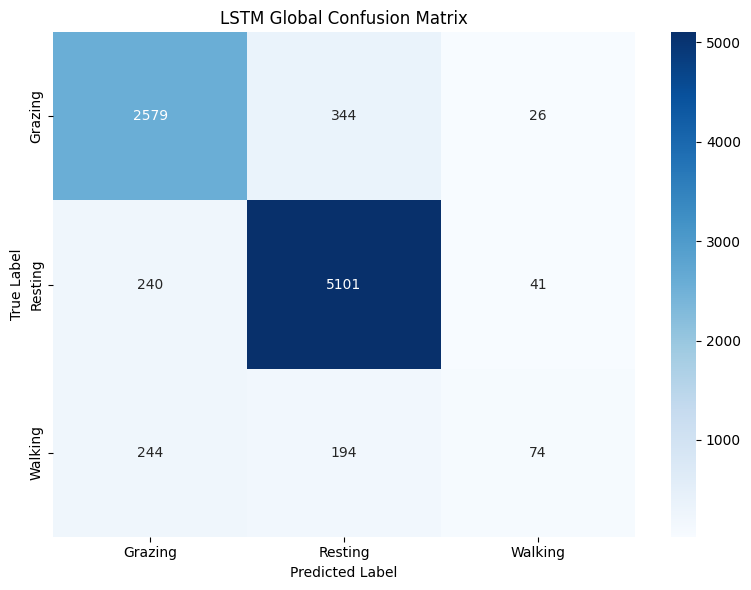

--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


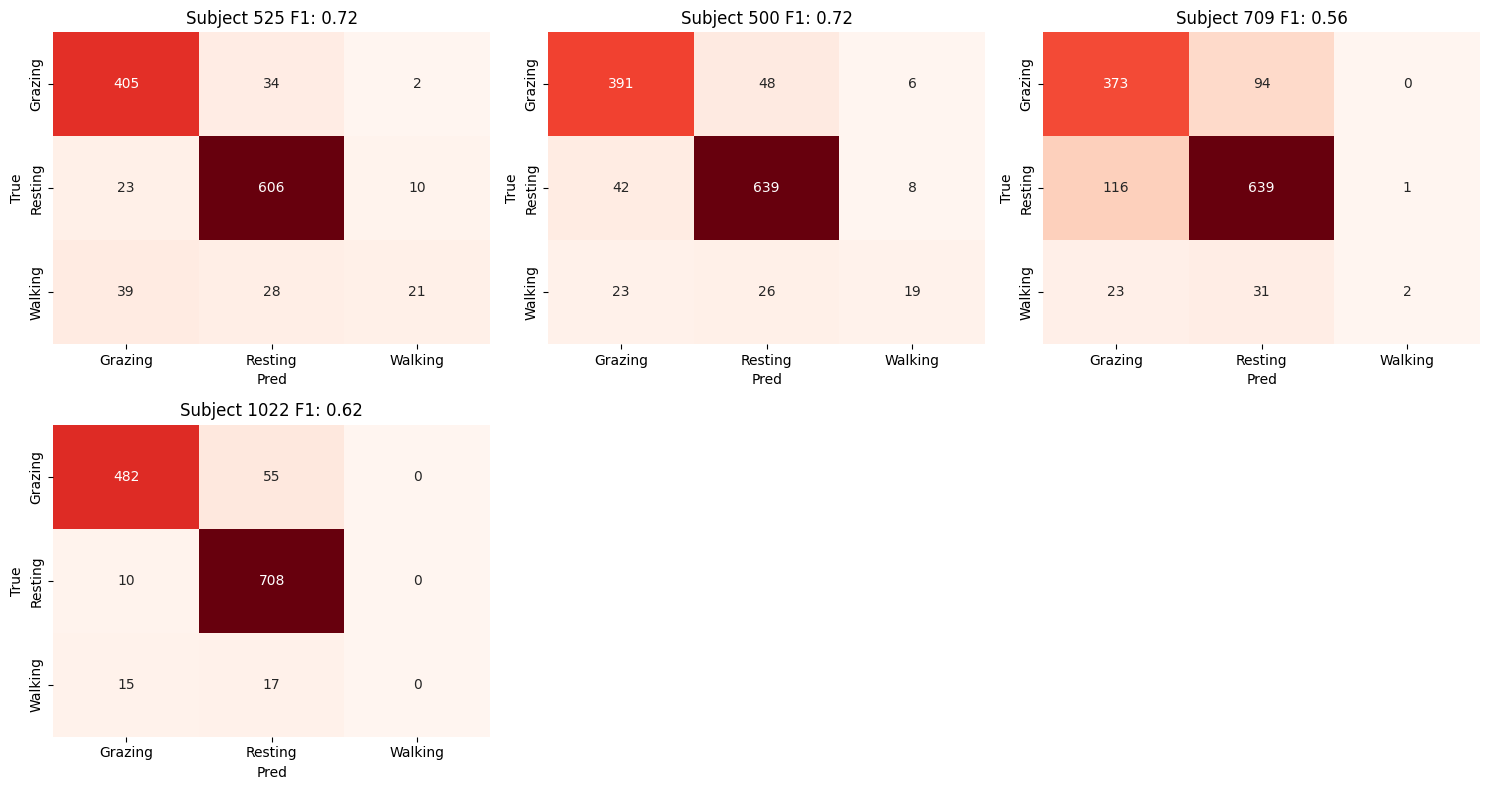

--- Training BiLSTM ---
Starting LOSO for BiLSTM on 7 subjects...
Overall BiLSTM Results:
(0.7825873465505486, 0.6628824439240782, 0.6815935934487389, None)


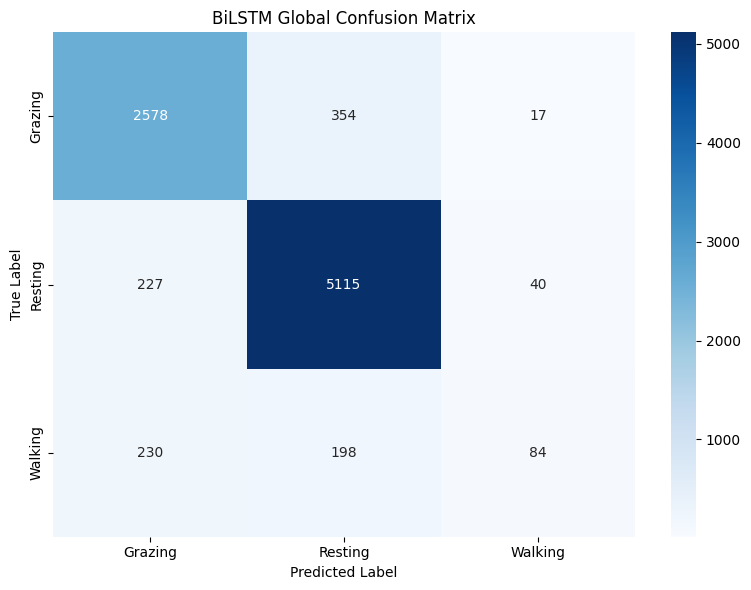

--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


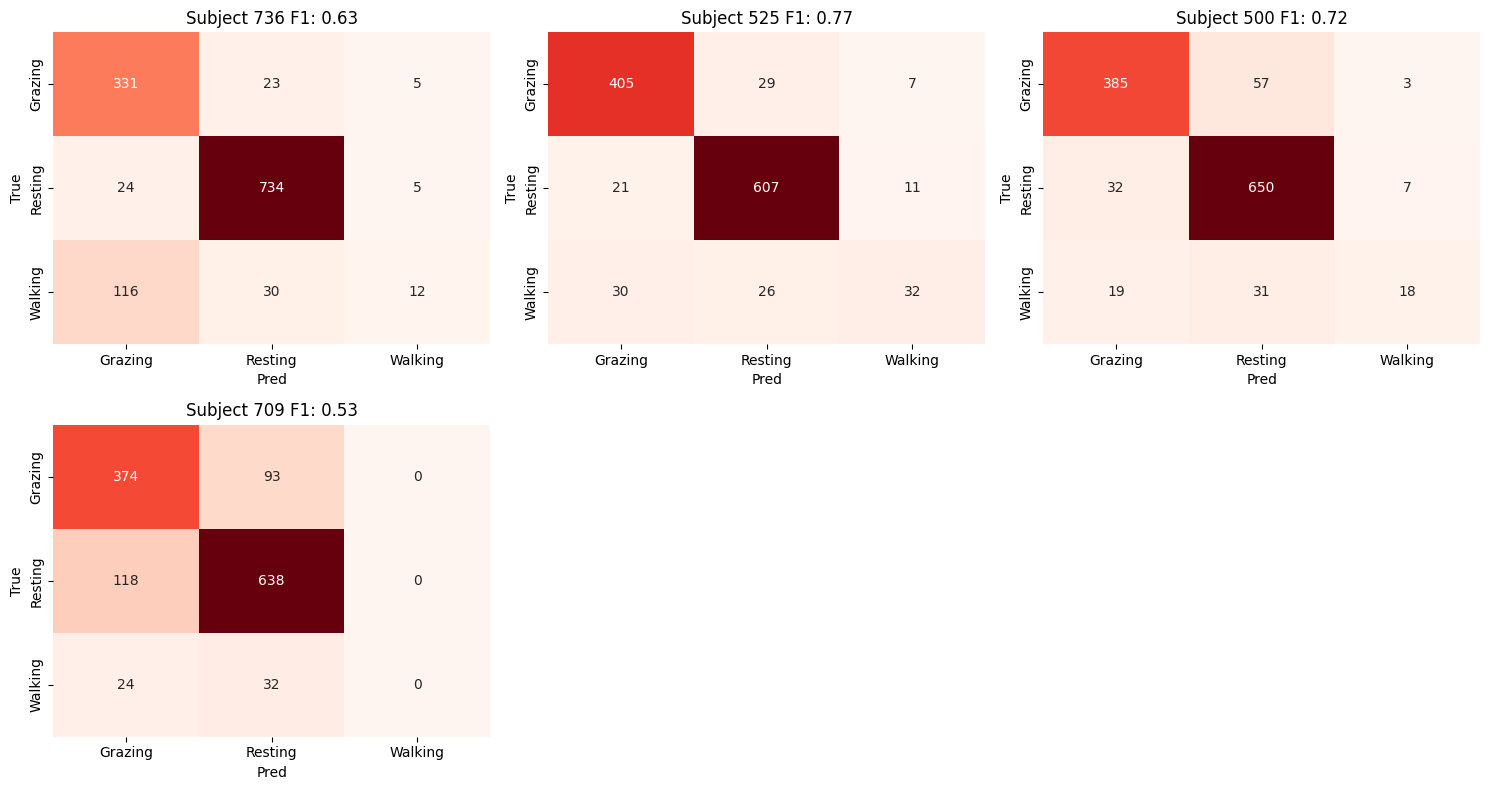

--- Training GatedConvNet ---
Starting LOSO for GatedConvNet on 7 subjects...
Overall GatedConvNet Results:
(0.7693878109374035, 0.659172572381309, 0.6723368663057444, None)


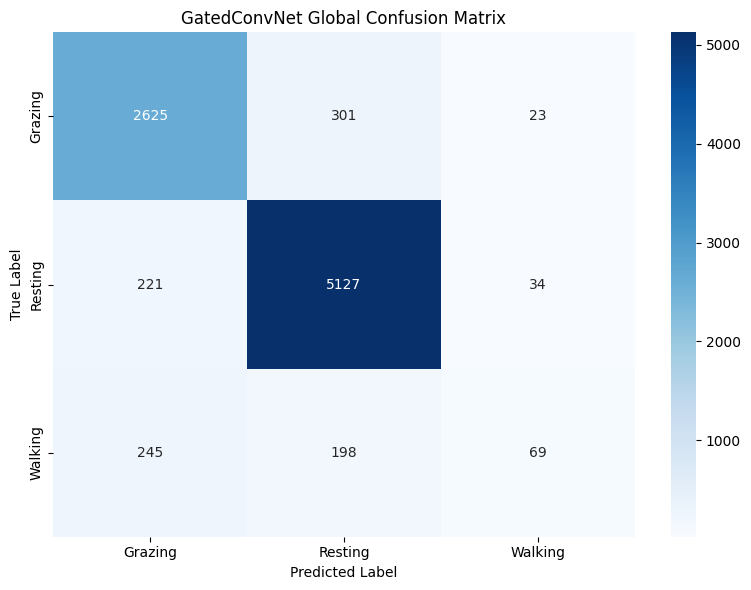

--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


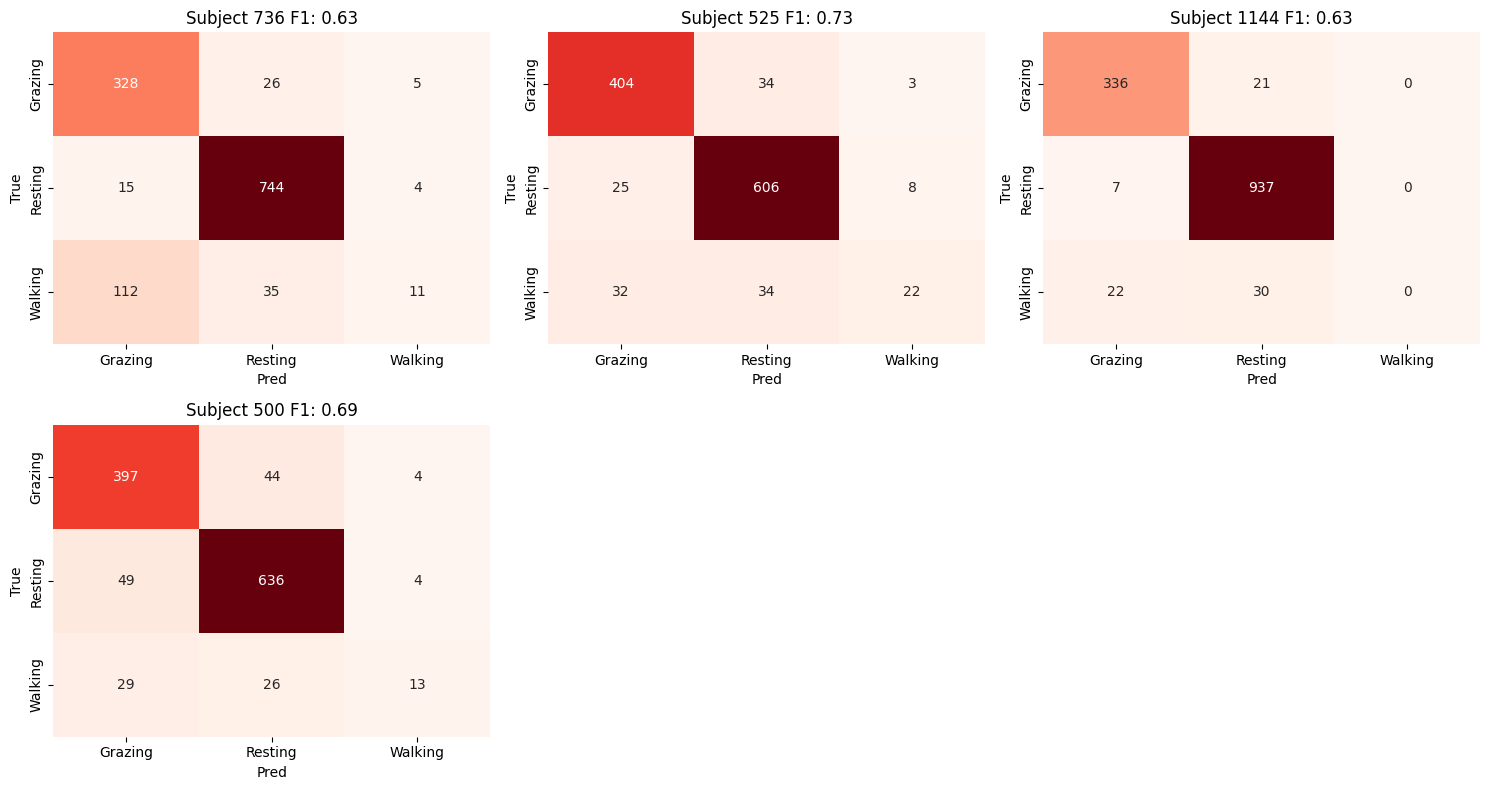

--- Training Transformer ---
Starting LOSO for Transformer on 7 subjects...
Overall Transformer Results:
(0.7680003661981073, 0.6727528416587184, 0.6919857172286125, None)


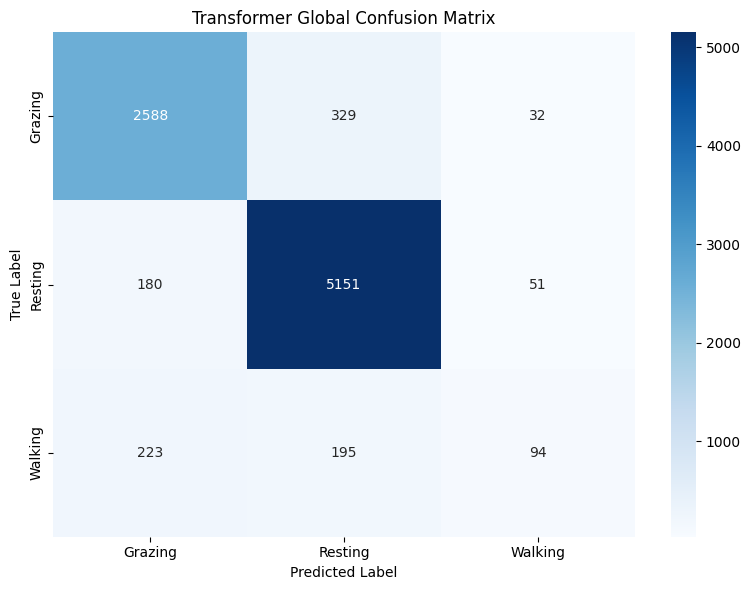

--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


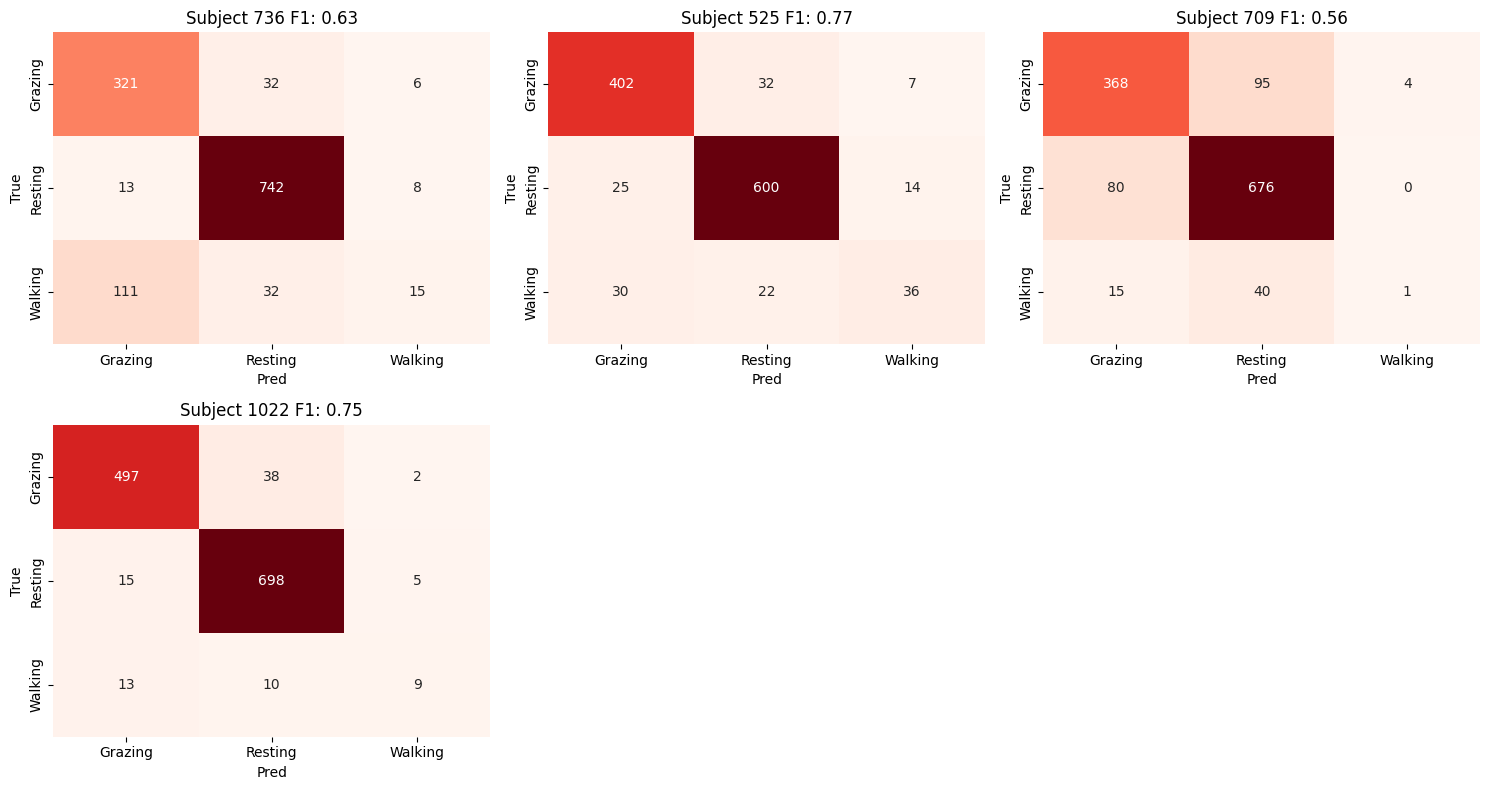

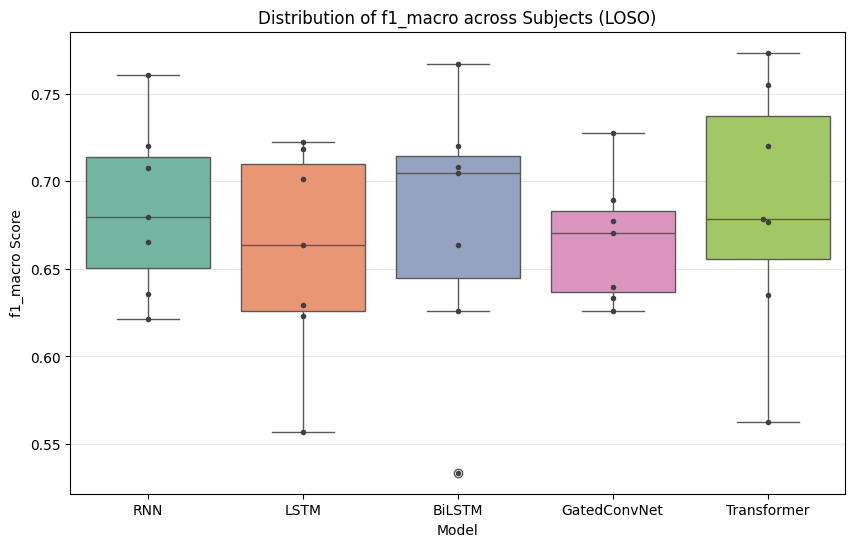

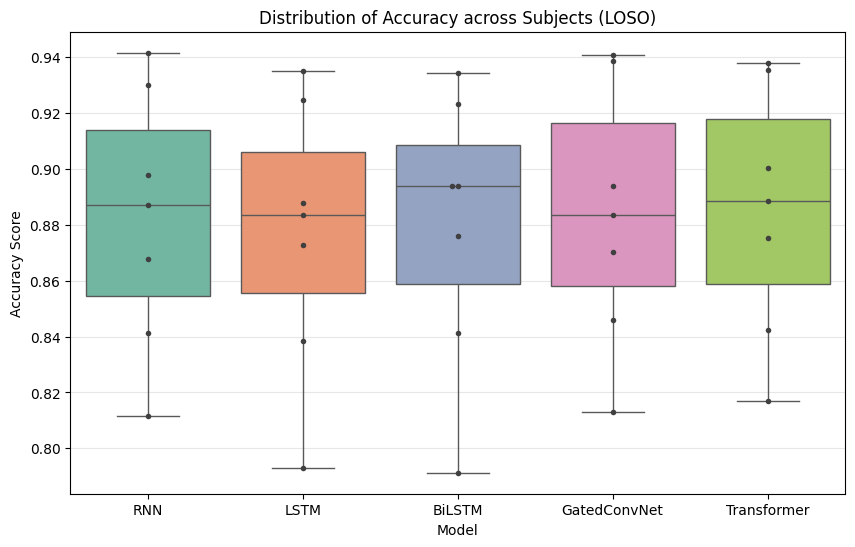

--- Visualizing Attention Map for Transformer Model ---


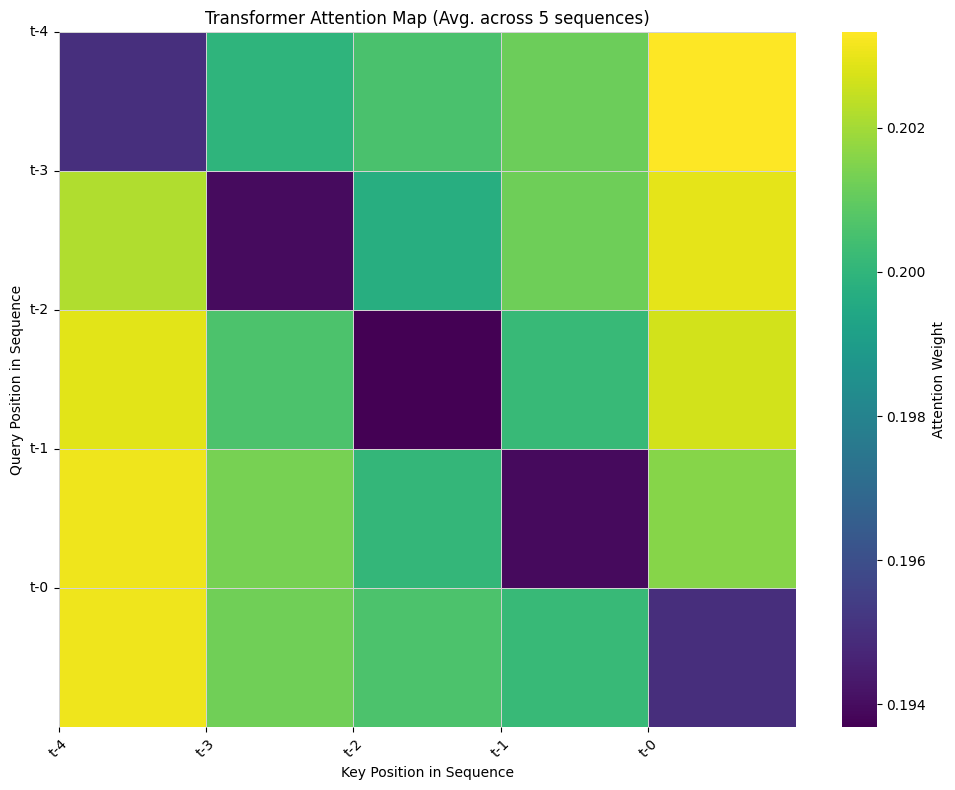

In [3]:
def run_loso(X, y, subjects, le, model_type, sequence_length):

    all_true, all_pred = [], []
    all_attention_weights = [] # To store attention weights for Transformer
    
    # Store metrics per subject for detailed visualization
    subject_results = {
        "subject": [], 
        "accuracy": [], 
        "f1_macro": [], 
        "y_true": [], 
        "y_pred": []
    }

    unique_subjects = np.unique(subjects)
    print(f"Starting LOSO for {model_type} on {len(unique_subjects)} subjects...")

    for test_subject in unique_subjects:

        tr = subjects != test_subject
        te = subjects == test_subject

        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        if len(np.unique(ytr)) < 2:
            print(f"Skipping subject {test_subject} due to insufficient classes in training data.")
            continue

        train_loader = DataLoader(
            TensorDataset(torch.tensor(Xtr).float(), torch.tensor(ytr)),
            batch_size=32, shuffle=True
        )
        test_loader = DataLoader(
            TensorDataset(torch.tensor(Xte).float(), torch.tensor(yte)),
            batch_size=32
        )

        # Model instantiation
        input_dim = X.shape[2]
        num_classes = len(le.classes_)
        
        model = None
        if model_type == "RNN":
            model = RNNModel(input_dim, 64, num_classes)
        elif model_type == "LSTM":
            model = LSTMModel(input_dim, 64, num_classes)
        elif model_type == "BiLSTM":
            model = BiLSTMModel(input_dim, 64, num_classes)
        elif model_type == "Transformer":
            model = TransformerModel(input_dim, heads=4, layers=2, classes=num_classes)
        elif model_type == "GatedConvNet":
            model = GatedConvNet(input_dim, sequence_length, hidden_dim=64, classes=num_classes)
        else:
            raise ValueError(f"Unknown model type: {model_type}")

        model.to(device)
        opt = optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.CrossEntropyLoss()

        best_loss = np.inf
        best_wts = copy.deepcopy(model.state_dict())
        patience, p = 5, 0

        # Quick Training Loop
        for epoch in range(15): # Reduced epochs for demo speed
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                
                if model_type == "Transformer":
                    logits, _ = model(xb)
                else:
                    logits = model(xb)

                loss = loss_fn(logits, yb)
                loss.backward()
                opt.step()

            # Validation on the LOOCV fold
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    if model_type == "Transformer":
                        logits, _ = model(xb)
                    else:
                        logits = model(xb)
                    val_loss += loss_fn(logits, yb).item()
            
            if val_loss < best_loss:
                best_loss = val_loss
                best_wts = copy.deepcopy(model.state_dict())
                p = 0
            else:
                p += 1
                if p >= patience:
                    break

        model.load_state_dict(best_wts)
        model.eval()

        preds = []
        current_attention_weights = []
        with torch.no_grad():
            for xb, _ in test_loader:
                xb = xb.to(device)
                if model_type == "Transformer":
                    logits, attn_weights = model(xb)
                    if attn_weights is not None:
                        current_attention_weights.append(attn_weights.cpu().numpy())
                else:
                    logits = model(xb)
                preds.extend(torch.argmax(logits, 1).cpu().numpy())

        # Accumulate Global Results
        all_true.extend(yte)
        all_pred.extend(preds)
        if model_type == "Transformer" and current_attention_weights:
             # Average attention weights across the batch for this subject if multiple batches
            avg_attn_weights_for_subject = np.mean(np.concatenate(current_attention_weights, axis=0), axis=0)
            all_attention_weights.append(avg_attn_weights_for_subject)

        # Accumulate Per-Subject Results
        acc = accuracy_score(yte, preds)
        f1 = f1_score(yte, preds, average='macro', zero_division=0)
        
        subject_results["subject"].append(test_subject)
        subject_results["accuracy"].append(acc)
        subject_results["f1_macro"].append(f1)
        subject_results["y_true"].append(yte)
        subject_results["y_pred"].append(np.array(preds))

    if model_type == "Transformer" and all_attention_weights:
        # Average attention weights across all test subjects for global attention map
        global_avg_attn_weights = np.mean(np.stack(all_attention_weights), axis=0)
        return np.array(all_true), np.array(all_pred), subject_results, global_avg_attn_weights
    
    return np.array(all_true), np.array(all_pred), subject_results, None


# --- Start of Notebook Cell ---
def plot_aggregate_confusion(y_true, y_pred, le, title):
    """Standard overall confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cmap="Blues"
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

def plot_per_subject_confusion(subject_results, le, num_to_plot=3):
    """
    Plots confusion matrices for individual animals.
    Limits to 'num_to_plot' to avoid clutter if you have many animals.
    """
    subjects = subject_results["subject"]
    
    # Sort subjects by F1 score to see best and worst performers
    # Handle cases where subject_results['f1_macro'] might be empty or contain NaNs
    if not subject_results['f1_macro']:
        print("No F1 macro scores available for plotting per-subject confusion.")
        return
        
    f1_scores = np.array(subject_results['f1_macro'])
    # Filter out NaNs if any, or handle them gracefully
    valid_indices = ~np.isnan(f1_scores)
    if not np.any(valid_indices):
        print("No valid F1 macro scores available for plotting per-subject confusion.")
        return
        
    sorted_indices = np.argsort(f1_scores[valid_indices])
    valid_subjects = np.array(subjects)[valid_indices]
    valid_f1_scores = f1_scores[valid_indices]

    worst_subs_display = [valid_subjects[i] for i in sorted_indices[:num_to_plot]]
    best_subs_display = [valid_subjects[i] for i in sorted_indices[-num_to_plot:]]
    
    target_subs = list(set(worst_subs_display + best_subs_display)) # Unique list of interesting subjects

    print(f"--- Plotting Individual Confusion Matrices (Best & Worst {num_to_plot}) ---")
    
    cols = 3
    rows = (len(target_subs) + cols - 1) // cols
    if rows == 0 and len(target_subs) > 0: rows = 1 # ensure at least one row if there are subjects
    
    if len(target_subs) == 0:
        print("No subjects to plot for individual confusion matrices.")
        return

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if rows * cols == 1: # If only one subplot, axes is not an array
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, sub in enumerate(target_subs):
        # Find index in original results (before filtering NaNs)
        original_list_idx = subjects.index(sub)
        y_t = subject_results["y_true"][original_list_idx]
        y_p = subject_results["y_pred"][original_list_idx]
        f1 = subject_results["f1_macro"][original_list_idx]

        cm = confusion_matrix(y_t, y_p, labels=range(len(le.classes_)))
        
        sns.heatmap(
            cm, annot=True, fmt="d", cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Reds", ax=axes[idx]
        )
        axes[idx].set_title(f"Subject {sub} F1: {f1:.2f}")
        axes[idx].set_xlabel("Pred")
        axes[idx].set_ylabel("True")

    # Hide unused subplots
    for i in range(len(target_subs), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_loso_boxplots(metrics_df, metric="f1_macro"):
    """
    Best visual for LOSO: Shows the variance in performance across animals.
    """
    if metrics_df.empty:
        print(f"No data for {metric} boxplots.")
        return
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=metrics_df, x="Model", y=metric, palette="Set2")
    sns.swarmplot(data=metrics_df, x="Model", y=metric, color=".25", size=4) # Shows individual dots
    plt.title(f"Distribution of {metric} across Subjects (LOSO)")
    plt.ylabel(f"{metric} Score")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def plot_feature_correlations(df, feats):
    """Heatmap of feature correlations to spot redundancy"""
    if df[feats].empty:
        print("No features to plot correlation.")
        return
    corr = df[feats].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Feature Correlation Matrix")
    plt.show()

def plot_class_balance(df, label_col="label"):
    """Check if some animals are missing specific behaviors"""
    if df.empty:
        print("No data for class balance plot.")
        return
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x="subject", hue=label_col)
    plt.title("Class Distribution per Subject")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_attention_map(attention_weights, sequence_length, feature_names, title="Attention Map"):    
    """
    Visualizes the attention weights from a Transformer model.
    Args:
        attention_weights (np.array): A 2D array of shape (sequence_length, sequence_length)
                                      representing the average attention weights. 
                                      Each row sums to 1 (attention from that position to all others).
        sequence_length (int): The length of the input sequences.
        feature_names (list): List of feature names (for x-axis labels if applicable).
        title (str): Title of the plot.
    """
    if attention_weights is None:
        print("No attention weights to plot.")
        return
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attention_weights, 
        cmap="viridis", 
        cbar_kws={'label': 'Attention Weight'},
        linewidths=.5,
        linecolor='lightgray'
    )
    plt.title(title + f" (Avg. across {attention_weights.shape[0]} sequences)")
    plt.xlabel("Key Position in Sequence")
    plt.ylabel("Query Position in Sequence")
    plt.xticks(np.arange(sequence_length), labels=[f't-{sequence_length-1-i}' for i in range(sequence_length)], rotation=45)
    plt.yticks(np.arange(sequence_length), labels=[f't-{sequence_length-1-i}' for i in range(sequence_length)], rotation=0)
    plt.tight_layout()
    plt.show()


# --- Start of Notebook Cell ---
# Ensure df_raw exists from previous cells
if 'df_raw' not in locals():
    print("df_raw not found. Please run data loading cells first.")
    # Exit or handle appropriately if df_raw is critical
else:
    df = df_raw.copy() # Use your loaded dataframe

    # --- Pipeline ---
    pipe = AdaptiveAccelPipeline(df)
    pipe.filter()
    pipe.features()
    df_r = pipe.resample(window=20, thresh=0.8)

    # --- Animal Count ---
    num_animals = df_r['subject'].nunique()
    print(f"==========================================")
    print(f" TOTAL NUMBER OF ANIMALS: {num_animals}")
    print(f"==========================================")

    # --- EDA Visuals ---
    feats = [c for c in df_r.columns if c not in ["subject","local_ts","label","label_enc"]]
    plot_feature_correlations(df_r, feats)
    plot_class_balance(df_r, label_col="label")

    # --- Prep Data ---
    le = LabelEncoder()
    df_r["label_enc"] = le.fit_transform(df_r["label"])
    df_r[feats] = StandardScaler().fit_transform(df_r[feats])
    
    sequence_length = 5 # As defined in the original notebook
    X, y, subjects = pipe.sequences(df_r, feats, "label_enc", steps=sequence_length)

    # --- Run All Models ---
    comparison_data = []

    models_to_run = ["RNN", "LSTM", "BiLSTM", "GatedConvNet", "Transformer"]
    attention_maps = {}

    for model_name in models_to_run:
        print(f"--- Training {model_name} ---")
        y_true, y_pred, sub_results, attn_weights = run_loso(X, y, subjects, le, model_name, sequence_length)
        
        # 1. Overall Metrics
        print(f"Overall {model_name} Results:")
        print(precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0))
        
        # 2. Aggregate Matrix
        plot_aggregate_confusion(y_true, y_pred, le, f"{model_name} Global Confusion Matrix")
        
        # 3. Individual Animal Matrices (New Req)
        plot_per_subject_confusion(sub_results, le, num_to_plot=2)
        
        # Store attention weights if available
        if model_name == "Transformer" and attn_weights is not None:
            attention_maps[model_name] = attn_weights

        # Collect data for boxplots
        for acc, f1 in zip(sub_results["accuracy"], sub_results["f1_macro"]):
            comparison_data.append({
                "Model": model_name,
                "Accuracy": acc,
                "f1_macro": f1
            })

    # --- Final Comparison Visualization ---
    if comparison_data:
        metrics_df = pd.DataFrame(comparison_data)
        plot_loso_boxplots(metrics_df, metric="f1_macro")
        plot_loso_boxplots(metrics_df, metric="Accuracy")

    # --- Attention Map Visualization ---
    if "Transformer" in attention_maps:
        print("--- Visualizing Attention Map for Transformer Model ---")
        plot_attention_map(attention_maps["Transformer"], sequence_length, feats, title="Transformer Attention Map")
